In [2]:
import sys
import os
import pandas as pd

sys.path.append(os.path.abspath('..'))

from src.database import engine

print("Conexão importada com sucesso!")

Conexão importada com sucesso!


In [ ]:
df_players = pd.read_sql("SELECT * FROM dim_players WHERE is_active = true", engine)

df_teams = pd.read_sql("SELECT * FROM dim_teams", engine)

df_players.head()

Matplotlib is building the font cache; this may take a moment.
C:\Users\guilh\AppData\Local\Temp\ipykernel_7500\1129450452.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_countries, x='total', y='country', palette='viridis')


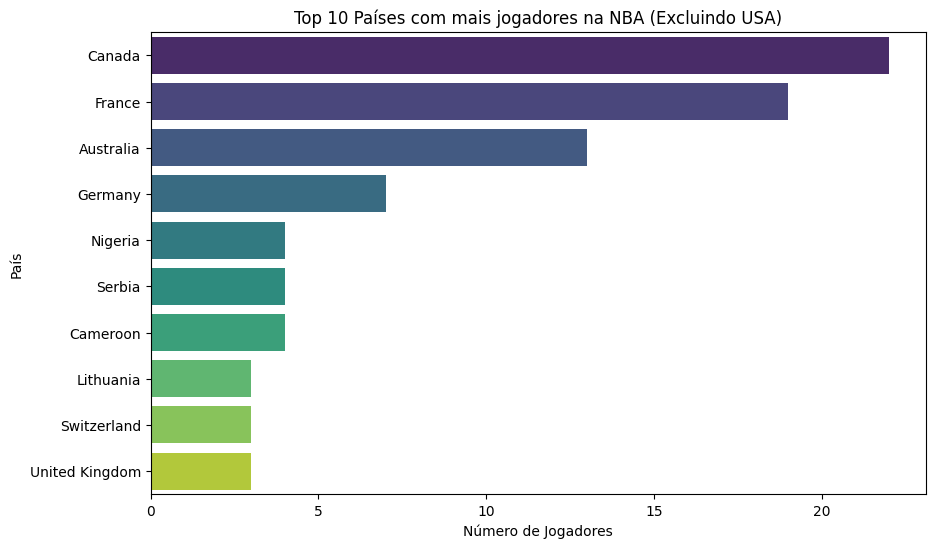

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SQL para pegar contagem por país
query = """
SELECT country, COUNT(*) as total 
FROM dim_players 
WHERE is_active = true AND country != 'USA'
GROUP BY country 
ORDER BY total DESC
LIMIT 10
"""
df_countries = pd.read_sql(query, engine)

# 2. Configura o visual do gráfico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_countries, x='total', y='country', palette='viridis')

# 3. Perfumaria (Títulos e Labels)
plt.title('Top 10 Países com mais jogadores na NBA (Excluindo USA)')
plt.xlabel('Número de Jogadores')
plt.ylabel('País')

# 4. Mostrar
plt.show()